# City-Specific ML Price Modelling

This workbook trains and compares price prediction models separately for Madrid and Tokyo using the model-ready datasets created in the previous stage.

The modelling round starts with the same family of models used in the original workbook, then extends it with Random Forest, Extra Trees, tuned XGBoost, LightGBM, CatBoost, cross-validation, listing-type checks and error analysis.


## 1. Setup and Imports


In [1]:
from pathlib import Path
import importlib.util
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas.api.types import is_numeric_dtype
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor

if importlib.util.find_spec("lightgbm"):
    from lightgbm import LGBMRegressor
else:
    LGBMRegressor = None

if importlib.util.find_spec("catboost"):
    from catboost import CatBoostRegressor
else:
    CatBoostRegressor = None

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42
CV_FOLDS = 3
TEST_SIZE = 0.20
MODEL_N_JOBS = 1
TARGET_COL = "log_price_eur"
PRICE_COL = "price_eur"

print("Optional models available:")
print("  LightGBM:", LGBMRegressor is not None)
print("  CatBoost:", CatBoostRegressor is not None)


Optional models available:
  LightGBM: True
  CatBoost: True


This loads the modelling libraries and keeps optional models graceful. If LightGBM or CatBoost are unavailable, the notebook skips them instead of failing.


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    """Find the CAPSTONE project folder from either the notebook folder or project root."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "1. Data").exists() and (candidate / "2. Code").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing '1. Data' and '2. Code'.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "1. Data"
MODEL_READY_DIR = DATA_DIR / "model_ready"
OUTPUT_DIR = DATA_DIR / "Outputs" / "ml_models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CITY_FILES = {
    "Madrid": MODEL_READY_DIR / "madrid_model_ready.csv",
    "Tokyo": MODEL_READY_DIR / "tokyo_model_ready.csv",
}

print("Project root:", PROJECT_ROOT)
print("Model-ready folder:", MODEL_READY_DIR)
print("ML output folder:", OUTPUT_DIR)


Project root: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE
Model-ready folder: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\model_ready
ML output folder: C:\Users\georg\Desktop\Docs\Student Files\CAPSTONE\1. Data\Outputs\ml_models


The path setup searches upward for the main CAPSTONE folder. This makes the notebook work whether Jupyter is opened from the project root or from the Stage 2 notebook folder.


## 2. Load Model-Ready City Datasets


In [3]:
datasets = {}
for city, file_path in CITY_FILES.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing model-ready file for {city}: {file_path}")
    df = pd.read_csv(file_path)
    datasets[city] = df
    print(f"{city}: {df.shape[0]:,} rows, {df.shape[1]:,} columns")

display(pd.DataFrame([
    {
        "city": city,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "target_mean_price_eur": round(df[PRICE_COL].mean(), 2),
        "target_median_price_eur": round(df[PRICE_COL].median(), 2),
    }
    for city, df in datasets.items()
]))


Madrid: 17,770 rows, 87 columns
Tokyo: 23,765 rows, 86 columns


,city,rows,columns,target_mean_price_eur,target_median_price_eur
0,Madrid,17770,87,114.60,105.00
1,Tokyo,23765,86,109.81,95.91


This reads the cleaned, model-ready datasets created earlier. The target remains the log-transformed euro price, while model performance is converted back to euro prices for easier interpretation.


## 3. Feature Setup and Baseline Reference


In [4]:
ORIGINAL_COMBINED_RESULTS = {
    "Linear Regression": {"rmse_eur": 43.3501, "mae_eur": 30.4450, "r2": 0.4464},
    "XGBoost": {"rmse_eur": 36.8795, "mae_eur": 25.8748, "r2": 0.5993},
}

This stores the original combined-dataset benchmark so the city-specific results can be compared later.

In [5]:
def split_features(df: pd.DataFrame):
    """Return X, y, numeric columns and categorical columns."""
    y = df[TARGET_COL].copy()
    X = df.drop(columns=[PRICE_COL, TARGET_COL]).copy()

    numeric_cols = [col for col in X.columns if is_numeric_dtype(X[col])]
    categorical_cols = [col for col in X.columns if col not in numeric_cols]
    return X, y, numeric_cols, categorical_cols

This function separates the model target from numeric and categorical predictors for each city.

In [6]:
feature_summary = []

In [7]:
for city, df in datasets.items():
    X, y, numeric_cols, categorical_cols = split_features(df)
    feature_summary.append({
        "city": city,
        "numeric_features": len(numeric_cols),
        "categorical_features": len(categorical_cols),
        "total_features": X.shape[1],
        "rows": len(df),
        "target": TARGET_COL,
    })

In [8]:
feature_summary_df = pd.DataFrame(feature_summary)

This table confirms how many numeric and categorical predictors are used for Madrid and Tokyo.

In [9]:
display(feature_summary_df)

,city,numeric_features,categorical_features,total_features,rows,target
0,Madrid,76,9,85,17770,log_price_eur
1,Tokyo,76,8,84,23765,log_price_eur


This table confirms how many numeric and categorical predictors are used for Madrid and Tokyo.

This separates predictors from the target and records the numeric and categorical feature counts. The original combined-data results are kept in the notebook so the city-specific results can be compared directly.


## 4. Preprocessing and Evaluation Helpers


In [10]:
def make_one_hot_encoder():
    """Return a dense one-hot encoder compatible with older and newer sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

This keeps one-hot encoding compatible across older and newer scikit-learn versions.

In [11]:
def build_preprocessor(numeric_cols, categorical_cols, scale_numeric=False):
    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline(steps=numeric_steps), numeric_cols),
            ("categorical", categorical_pipeline, categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

This builds the shared numeric and categorical preprocessing pipeline used by every model.

In [12]:
def to_euros(log_values):
    return np.expm1(np.asarray(log_values))

This converts log-price predictions back into euro prices for interpretation.

In [13]:
def evaluate_on_euros(y_true_log, y_pred_log):
    y_true = to_euros(y_true_log)
    y_pred = np.maximum(to_euros(y_pred_log), 0)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "rmse_eur": round(rmse, 4),
        "mae_eur": round(mean_absolute_error(y_true, y_pred), 4),
        "r2": round(r2_score(y_true, y_pred), 4),
    }

This calculates RMSE, MAE, and R2 on euro prices rather than log prices.

In [14]:
def euro_rmse_score(y_true_log, y_pred_log):
    y_true = to_euros(y_true_log)
    y_pred = np.maximum(to_euros(y_pred_log), 0)
    return np.sqrt(mean_squared_error(y_true, y_pred))

This scoring helper lets cross-validation evaluate model error in euros.

In [15]:
def euro_mae_score(y_true_log, y_pred_log):
    y_true = to_euros(y_true_log)
    y_pred = np.maximum(to_euros(y_pred_log), 0)
    return mean_absolute_error(y_true, y_pred)

This scoring helper lets cross-validation evaluate model error in euros.

In [16]:
rmse_scorer = make_scorer(euro_rmse_score, greater_is_better=False)

These scorer objects plug the euro-based metrics into cross-validation.

In [17]:
mae_scorer = make_scorer(euro_mae_score, greater_is_better=False)

These scorer objects plug the euro-based metrics into cross-validation.

In [18]:
r2_scorer = make_scorer(lambda y_true, y_pred: r2_score(to_euros(y_true), np.maximum(to_euros(y_pred), 0)))

These scorer objects plug the euro-based metrics into cross-validation.

In [19]:
def clean_feature_name(feature_name: str) -> str:
    return (
        feature_name
        .replace("numeric__", "")
        .replace("categorical__", "")
        .replace("_", " ")
    )

This cleans transformed feature names before displaying feature importance.

The preprocessing pipeline imputes missing numeric values, one-hot encodes categorical attributes and keeps all models on the same feature representation. The scoring helpers train on log price but report RMSE, MAE and R2 in euro terms.


## 5. Model Lineup


In [20]:
def model_specs(numeric_cols, categorical_cols):
    specs = {}

    specs["Linear Regression"] = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols, scale_numeric=True)),
            ("model", LinearRegression()),
        ]
    )

    specs["Decision Tree"] = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
            ("model", DecisionTreeRegressor(max_depth=12, min_samples_leaf=20, random_state=RANDOM_STATE)),
        ]
    )

    specs["Random Forest"] = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
            ("model", RandomForestRegressor(
                n_estimators=150,
                max_depth=24,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=MODEL_N_JOBS,
            )),
        ]
    )

    specs["Extra Trees"] = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
            ("model", ExtraTreesRegressor(
                n_estimators=150,
                max_depth=24,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=MODEL_N_JOBS,
            )),
        ]
    )

    specs["XGBoost"] = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
            ("model", XGBRegressor(
                n_estimators=300,
                learning_rate=0.04,
                max_depth=4,
                subsample=0.85,
                colsample_bytree=0.85,
                objective="reg:squarederror",
                eval_metric="rmse",
                random_state=RANDOM_STATE,
                n_jobs=MODEL_N_JOBS,
            )),
        ]
    )

    if LGBMRegressor is not None:
        specs["LightGBM"] = Pipeline(
            steps=[
                ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
                ("model", LGBMRegressor(
                    n_estimators=350,
                    learning_rate=0.04,
                    max_depth=-1,
                    num_leaves=31,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    objective="regression",
                    random_state=RANDOM_STATE,
                    n_jobs=MODEL_N_JOBS,
                    verbose=-1,
                )),
            ]
        )

    if CatBoostRegressor is not None:
        specs["CatBoost"] = Pipeline(
            steps=[
                ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
                ("model", CatBoostRegressor(
                    iterations=350,
                    learning_rate=0.05,
                    depth=6,
                    loss_function="RMSE",
                    random_seed=RANDOM_STATE,
                    verbose=False,
                    allow_writing_files=False,
                    thread_count=MODEL_N_JOBS,
                )),
            ]
        )

    return specs

This function defines the model lineup: Linear Regression, Decision Tree, Random Forest, Extra Trees, XGBoost, LightGBM, and CatBoost where available.

In [21]:
sample_city = next(iter(datasets))
_, _, sample_numeric, sample_categorical = split_features(datasets[sample_city])
print("Models included:")
for model_name in model_specs(sample_numeric, sample_categorical):
    print(" -", model_name)

Models included:
 - Linear Regression
 - Decision Tree
 - Random Forest
 - Extra Trees
 - XGBoost
 - LightGBM
 - CatBoost


This preview confirms which models are available in the current Python environment.

This starts with Abrils's model families, then adds the ensemble methods we want to test: Random Forest, Extra Trees, LightGBM and CatBoost. XGBoost remains the current benchmark.


## 6. Cross-Validation Round


In [22]:
cv_rows = []
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

for city, df in datasets.items():
    X, y, numeric_cols, categorical_cols = split_features(df)
    print(f"Running {CV_FOLDS}-fold cross-validation for {city}...")

    for model_name, pipeline in model_specs(numeric_cols, categorical_cols).items():
        scores = cross_validate(
            pipeline,
            X,
            y,
            scoring={"rmse": rmse_scorer, "mae": mae_scorer, "r2": r2_scorer},
            cv=cv,
            n_jobs=1,
            error_score="raise",
        )
        row = {
            "city": city,
            "model": model_name,
            "cv_rmse_mean": round(-scores["test_rmse"].mean(), 4),
            "cv_rmse_std": round(scores["test_rmse"].std(), 4),
            "cv_mae_mean": round(-scores["test_mae"].mean(), 4),
            "cv_mae_std": round(scores["test_mae"].std(), 4),
            "cv_r2_mean": round(scores["test_r2"].mean(), 4),
            "cv_r2_std": round(scores["test_r2"].std(), 4),
        }
        cv_rows.append(row)
        print(f"  {model_name}: RMSE {row['cv_rmse_mean']:.2f}, MAE {row['cv_mae_mean']:.2f}, R2 {row['cv_r2_mean']:.4f}")

cv_results_df = pd.DataFrame(cv_rows).sort_values(["city", "cv_rmse_mean"])
cv_results_df.to_csv(OUTPUT_DIR / "expanded_city_cv_results.csv", index=False)
display(cv_results_df)


Running 3-fold cross-validation for Madrid...
  Linear Regression: RMSE 39.51, MAE 26.13, R2 0.5962
  Decision Tree: RMSE 40.06, MAE 27.74, R2 0.5866
  Random Forest: RMSE 33.42, MAE 22.21, R2 0.7121
  Extra Trees: RMSE 32.88, MAE 21.75, R2 0.7215
  XGBoost: RMSE 33.76, MAE 22.91, R2 0.7063
  LightGBM: RMSE 31.82, MAE 21.31, R2 0.7391
  CatBoost: RMSE 33.23, MAE 22.42, R2 0.7154
Running 3-fold cross-validation for Tokyo...
  Linear Regression: RMSE 37.76, MAE 26.21, R2 0.5467
  Decision Tree: RMSE 38.33, MAE 26.82, R2 0.5330
  Random Forest: RMSE 31.63, MAE 20.97, R2 0.6821
  Extra Trees: RMSE 30.72, MAE 19.74, R2 0.7000
  XGBoost: RMSE 32.80, MAE 22.81, R2 0.6582
  LightGBM: RMSE 30.52, MAE 20.84, R2 0.7040
  CatBoost: RMSE 32.16, MAE 22.34, R2 0.6712


,city,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std
5,Madrid,LightGBM,31.8219,0.2530,21.3079,0.1806,0.7391,0.0026
3,Madrid,Extra Trees,32.8775,0.0906,21.7475,0.0560,0.7215,0.0029
6,Madrid,CatBoost,33.2345,0.0669,22.4204,0.0493,0.7154,0.0014
2,Madrid,Random Forest,33.4247,0.1123,22.2146,0.1349,0.7121,0.0009
4,Madrid,XGBoost,33.7595,0.1354,22.9053,0.1235,0.7063,0.0004
0,Madrid,Linear Regression,39.5130,2.1635,26.1343,0.1689,0.5962,0.0478
1,Madrid,Decision Tree,40.0557,0.1799,27.7401,0.2419,0.5866,0.0012
12,Tokyo,LightGBM,30.5181,0.3177,20.8394,0.2775,0.7040,0.0034
10,Tokyo,Extra Trees,30.7238,0.3800,19.7368,0.2773,0.7000,0.0042
9,Tokyo,Random Forest,31.6266,0.4582,20.9667,0.3373,0.6821,0.0059


Cross-validation repeats the train/test exercise across several splits. This gives a more stable view of which models are genuinely stronger, rather than relying on one lucky split.


## 7. Random Forest Iterations


In [23]:
def tune_random_forest(X_train, y_train, numeric_cols, categorical_cols):
    rf_pipeline = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=MODEL_N_JOBS)),
        ]
    )

    param_distributions = {
        "model__n_estimators": [100, 150, 250],
        "model__max_depth": [16, 24, None],
        "model__min_samples_leaf": [1, 2, 5],
        "model__max_features": ["sqrt", 0.7, 1.0],
    }

    search = RandomizedSearchCV(
        estimator=rf_pipeline,
        param_distributions=param_distributions,
        n_iter=4,
        scoring=rmse_scorer,
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=0,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    return search

This function defines the compact Random Forest hyperparameter search.

In [24]:
rf_tuning_rows = []
rf_best_models = {}

for city, df in datasets.items():
    X, y, numeric_cols, categorical_cols = split_features(df)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Tuning Random Forest for {city}...")
    search = tune_random_forest(X_train, y_train, numeric_cols, categorical_cols)
    rf_best_models[city] = search.best_estimator_

    cv_results = pd.DataFrame(search.cv_results_)
    for _, row in cv_results.sort_values("rank_test_score").iterrows():
        params = row["params"]
        rf_tuning_rows.append({
            "city": city,
            "rank": int(row["rank_test_score"]),
            "cv_rmse_eur": round(-row["mean_test_score"], 4),
            "cv_rmse_std": round(row["std_test_score"], 4),
            "n_estimators": params.get("model__n_estimators"),
            "max_depth": params.get("model__max_depth"),
            "min_samples_leaf": params.get("model__min_samples_leaf"),
            "max_features": params.get("model__max_features"),
        })

rf_tuning_df = pd.DataFrame(rf_tuning_rows).sort_values(["city", "rank"])
rf_tuning_df.to_csv(OUTPUT_DIR / "random_forest_tuning_results.csv", index=False)
display(rf_tuning_df)

Tuning Random Forest for Madrid...
Tuning Random Forest for Tokyo...


,city,rank,cv_rmse_eur,cv_rmse_std,n_estimators,max_depth,min_samples_leaf,max_features
0,Madrid,1,34.2662,0.2156,150,16,2,1.0
1,Madrid,2,35.8367,0.4576,150,24,2,sqrt
2,Madrid,3,35.9048,0.4420,100,24,2,sqrt
3,Madrid,4,36.1107,0.4489,100,16,1,sqrt
4,Tokyo,1,32.7376,0.2154,150,16,2,1.0
5,Tokyo,2,34.2994,0.1575,150,24,2,sqrt
6,Tokyo,3,34.3583,0.1724,100,24,2,sqrt
7,Tokyo,4,35.0277,0.2213,100,16,1,sqrt


This cell runs the Random Forest search separately for Madrid and Tokyo and stores the best model for each city.

This runs a compact Random Forest tuning loop. The aim is not to exhaust every possible setting, but to test whether stronger forest settings can challenge XGBoost without making the notebook painfully slow.


## 8. Tuned XGBoost Search


In [25]:
def tune_xgboost(X_train, y_train, numeric_cols, categorical_cols):
    xgb_pipeline = Pipeline(
        steps=[
            ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
            ("model", XGBRegressor(
                objective="reg:squarederror",
                eval_metric="rmse",
                random_state=RANDOM_STATE,
                n_jobs=MODEL_N_JOBS,
            )),
        ]
    )

    param_distributions = {
        "model__n_estimators": [200, 300, 450],
        "model__learning_rate": [0.025, 0.04, 0.06, 0.08],
        "model__max_depth": [3, 4, 5, 6],
        "model__subsample": [0.75, 0.85, 0.95],
        "model__colsample_bytree": [0.75, 0.85, 0.95],
        "model__reg_lambda": [1, 3, 5, 8],
        "model__min_child_weight": [1, 3, 5],
    }

    search = RandomizedSearchCV(
        estimator=xgb_pipeline,
        param_distributions=param_distributions,
        n_iter=6,
        scoring=rmse_scorer,
        cv=CV_FOLDS,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbose=0,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    return search

This function defines the compact XGBoost tuning search around the strongest previous settings.

In [26]:
xgb_tuning_rows = []
xgb_best_models = {}

for city, df in datasets.items():
    X, y, numeric_cols, categorical_cols = split_features(df)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )
    print(f"Tuning XGBoost for {city}...")
    search = tune_xgboost(X_train, y_train, numeric_cols, categorical_cols)
    xgb_best_models[city] = search.best_estimator_

    cv_results = pd.DataFrame(search.cv_results_)
    for _, row in cv_results.sort_values("rank_test_score").iterrows():
        params = row["params"]
        xgb_tuning_rows.append({
            "city": city,
            "rank": int(row["rank_test_score"]),
            "cv_rmse_eur": round(-row["mean_test_score"], 4),
            "cv_rmse_std": round(row["std_test_score"], 4),
            "n_estimators": params.get("model__n_estimators"),
            "learning_rate": params.get("model__learning_rate"),
            "max_depth": params.get("model__max_depth"),
            "subsample": params.get("model__subsample"),
            "colsample_bytree": params.get("model__colsample_bytree"),
            "reg_lambda": params.get("model__reg_lambda"),
            "min_child_weight": params.get("model__min_child_weight"),
        })

xgb_tuning_df = pd.DataFrame(xgb_tuning_rows).sort_values(["city", "rank"])
xgb_tuning_df.to_csv(OUTPUT_DIR / "xgboost_tuning_results.csv", index=False)
display(xgb_tuning_df)

Tuning XGBoost for Madrid...
Tuning XGBoost for Tokyo...


,city,rank,cv_rmse_eur,cv_rmse_std,n_estimators,learning_rate,max_depth,subsample,colsample_bytree,reg_lambda,min_child_weight
0,Madrid,1,31.0976,0.3039,450,0.080,6,0.75,0.85,1,5
1,Madrid,2,31.7712,0.1388,450,0.040,6,0.95,0.75,5,5
2,Madrid,3,33.0186,0.3083,450,0.025,5,0.85,0.95,3,5
3,Madrid,4,33.1265,0.2212,450,0.080,3,0.95,0.85,5,3
4,Madrid,5,33.6022,0.3314,450,0.060,3,0.85,0.95,8,5
5,Madrid,6,34.3690,0.4005,450,0.040,3,0.85,0.75,8,1
6,Tokyo,1,29.6778,0.2620,450,0.080,6,0.75,0.85,1,5
7,Tokyo,2,30.3229,0.3165,450,0.040,6,0.95,0.75,5,5
8,Tokyo,3,31.9310,0.2450,450,0.025,5,0.85,0.95,3,5
9,Tokyo,4,32.1749,0.3852,450,0.080,3,0.95,0.85,5,3


This cell runs the tuned XGBoost search for each city when XGBoost is installed.

This tunes XGBoost around the current strong configuration. The search is intentionally compact so that it is practical to rerun during project work.


## 9. Final Train/Test Comparison


In [27]:
all_results = []
all_predictions = []
trained_models = {}

for city, df in datasets.items():
    print(f"Training final model comparison for {city}...")
    X, y, numeric_cols, categorical_cols = split_features(df)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
    )

    specs = model_specs(numeric_cols, categorical_cols)
    specs["Random Forest Tuned"] = rf_best_models[city]
    specs["XGBoost Tuned"] = xgb_best_models[city]
    trained_models[city] = {}

    for model_name, pipeline in specs.items():
        pipeline.fit(X_train, y_train)
        y_pred_log = pipeline.predict(X_test)
        metrics = evaluate_on_euros(y_test, y_pred_log)

        result = {
            "scope": "City-specific",
            "city": city,
            "model": model_name,
            "train_rows": len(X_train),
            "test_rows": len(X_test),
            "numeric_features": len(numeric_cols),
            "categorical_features": len(categorical_cols),
            **metrics,
        }
        all_results.append(result)
        trained_models[city][model_name] = pipeline

        pred_df = X_test.copy()
        pred_df["city"] = city
        pred_df["model"] = model_name
        pred_df["actual_price_eur"] = to_euros(y_test)
        pred_df["predicted_price_eur"] = np.maximum(to_euros(y_pred_log), 0)
        pred_df["residual_eur"] = pred_df["actual_price_eur"] - pred_df["predicted_price_eur"]
        pred_df["abs_error_eur"] = pred_df["residual_eur"].abs()
        all_predictions.append(pred_df)

results_df = pd.DataFrame(all_results).sort_values(["city", "rmse_eur"])
predictions_df = pd.concat(all_predictions, ignore_index=True)

results_df.to_csv(OUTPUT_DIR / "expanded_city_model_results.csv", index=False)
predictions_df.to_csv(OUTPUT_DIR / "expanded_city_model_predictions.csv", index=False)

display(results_df)


Training final model comparison for Madrid...
Training final model comparison for Tokyo...


,scope,city,model,train_rows,test_rows,numeric_features,categorical_features,rmse_eur,mae_eur,r2
8,City-specific,Madrid,XGBoost Tuned,14216,3554,76,9,30.5866,20.4066,0.7624
5,City-specific,Madrid,LightGBM,14216,3554,76,9,31.7541,21.2820,0.7439
3,City-specific,Madrid,Extra Trees,14216,3554,76,9,32.4149,21.3922,0.7331
2,City-specific,Madrid,Random Forest,14216,3554,76,9,33.0438,21.9651,0.7227
6,City-specific,Madrid,CatBoost,14216,3554,76,9,33.0849,22.2698,0.7220
7,City-specific,Madrid,Random Forest Tuned,14216,3554,76,9,33.2411,22.1503,0.7193
4,City-specific,Madrid,XGBoost,14216,3554,76,9,33.8341,22.8707,0.7092
0,City-specific,Madrid,Linear Regression,14216,3554,76,9,38.1337,26.3796,0.6306
1,City-specific,Madrid,Decision Tree,14216,3554,76,9,39.7007,27.8778,0.5997
17,City-specific,Tokyo,XGBoost Tuned,19012,4753,76,8,28.5527,18.9469,0.7372


This is the main holdout-set comparison. It evaluates every candidate model on the same city-specific train/test split and saves the predictions for later residual analysis.


## 10. Compare Against Original Combined Model


In [28]:
comparison_rows = []

for city in results_df["city"].unique():
    city_results = results_df[results_df["city"] == city].copy()
    best_row = city_results.sort_values("rmse_eur").iloc[0]
    xgb_row = city_results[city_results["model"] == "XGBoost"].iloc[0]

    for label, row in [("Best city-specific model", best_row), ("City-specific XGBoost", xgb_row)]:
        original = ORIGINAL_COMBINED_RESULTS["XGBoost"]
        comparison_rows.append({
            "city": city,
            "comparison_scope": label,
            "city_model": row["model"],
            "city_rmse_eur": row["rmse_eur"],
            "city_mae_eur": row["mae_eur"],
            "city_r2": row["r2"],
            "original_reference_model": "Combined-data XGBoost",
            "original_rmse_eur": original["rmse_eur"],
            "original_mae_eur": original["mae_eur"],
            "original_r2": original["r2"],
            "rmse_change_vs_original": round(row["rmse_eur"] - original["rmse_eur"], 4),
            "mae_change_vs_original": round(row["mae_eur"] - original["mae_eur"], 4),
            "r2_change_vs_original": round(row["r2"] - original["r2"], 4),
        })

expanded_comparison_df = pd.DataFrame(comparison_rows)
expanded_comparison_df.to_csv(OUTPUT_DIR / "expanded_city_vs_original_comparison.csv", index=False)
display(expanded_comparison_df)


,city,comparison_scope,city_model,city_rmse_eur,city_mae_eur,city_r2,original_reference_model,original_rmse_eur,original_mae_eur,original_r2,rmse_change_vs_original,mae_change_vs_original,r2_change_vs_original
0,Madrid,Best city-specific model,XGBoost Tuned,30.5866,20.4066,0.7624,Combined-data XGBoost,36.8795,25.8748,0.5993,-6.2929,-5.4682,0.1631
1,Madrid,City-specific XGBoost,XGBoost,33.8341,22.8707,0.7092,Combined-data XGBoost,36.8795,25.8748,0.5993,-3.0454,-3.0041,0.1099
2,Tokyo,Best city-specific model,XGBoost Tuned,28.5527,18.9469,0.7372,Combined-data XGBoost,36.8795,25.8748,0.5993,-8.3268,-6.9279,0.1379
3,Tokyo,City-specific XGBoost,XGBoost,32.3619,22.4560,0.6623,Combined-data XGBoost,36.8795,25.8748,0.5993,-4.5176,-3.4188,0.0630


This compares both the plain city-specific XGBoost and the best model from the expanded round against the original combined-data XGBoost result.


## 11. Metric Charts


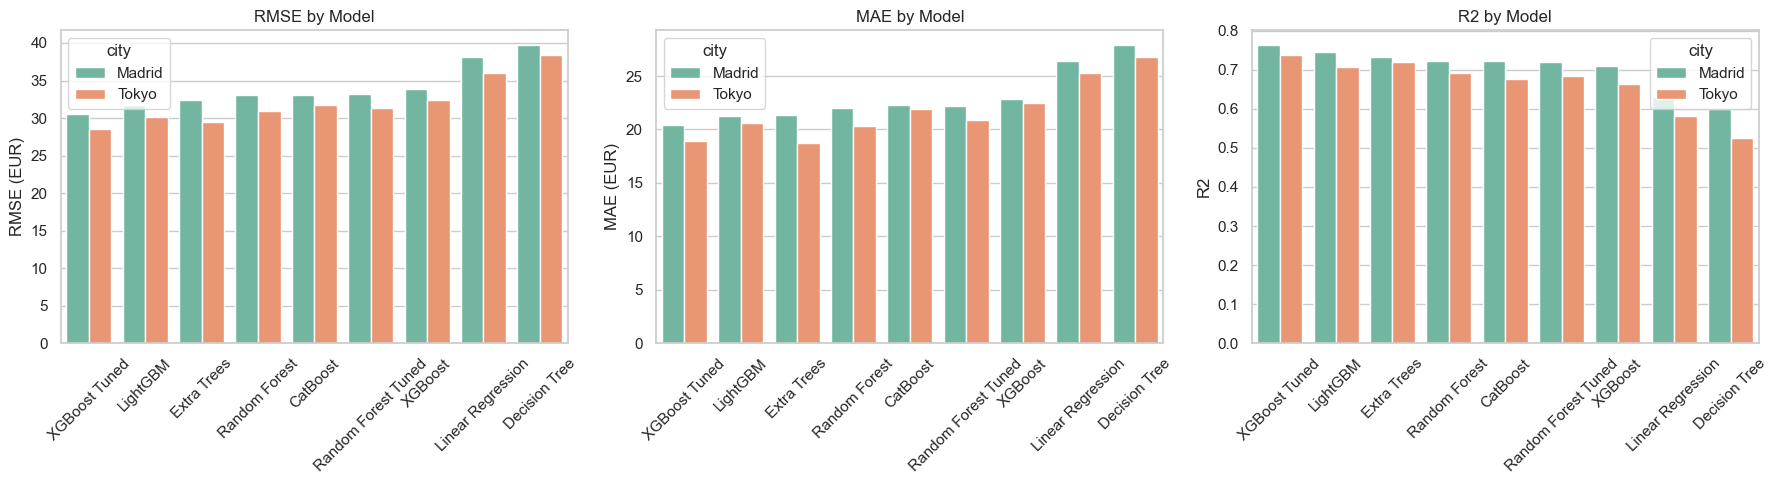

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=results_df, x="model", y="rmse_eur", hue="city", ax=axes[0])
axes[0].set_title("RMSE by Model")
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE (EUR)")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=results_df, x="model", y="mae_eur", hue="city", ax=axes[1])
axes[1].set_title("MAE by Model")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE (EUR)")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(data=results_df, x="model", y="r2", hue="city", ax=axes[2])
axes[2].set_title("R2 by Model")
axes[2].set_xlabel("")
axes[2].set_ylabel("R2")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


These charts make the comparison easier to read. Lower RMSE and MAE are better, while higher R2 is better.


## 12. Feature Importance


In [30]:
def get_feature_names(pipeline):
    preprocessor = pipeline.named_steps["preprocess"]
    names = preprocessor.get_feature_names_out()
    return [clean_feature_name(name) for name in names]

This helper retrieves readable feature names after preprocessing.

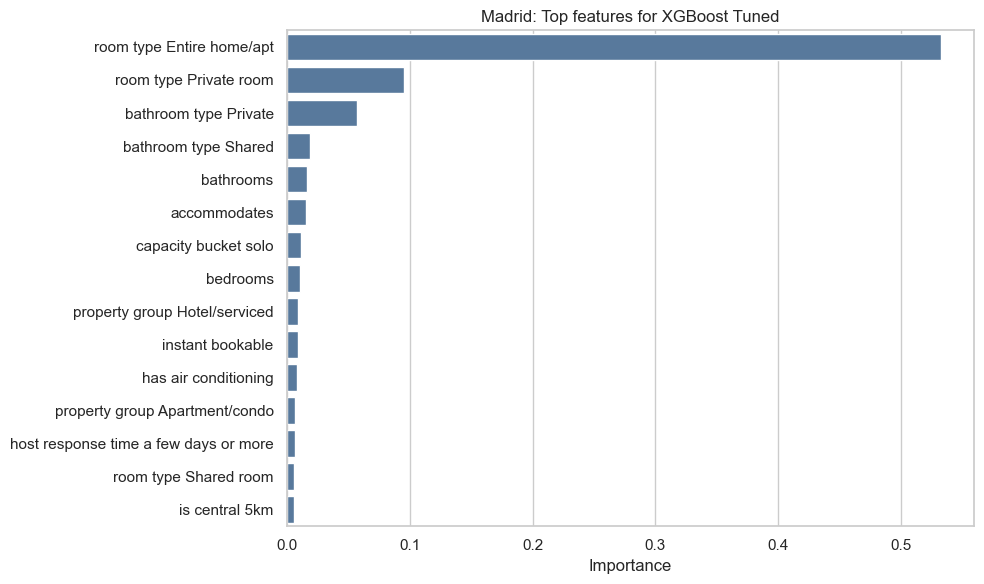

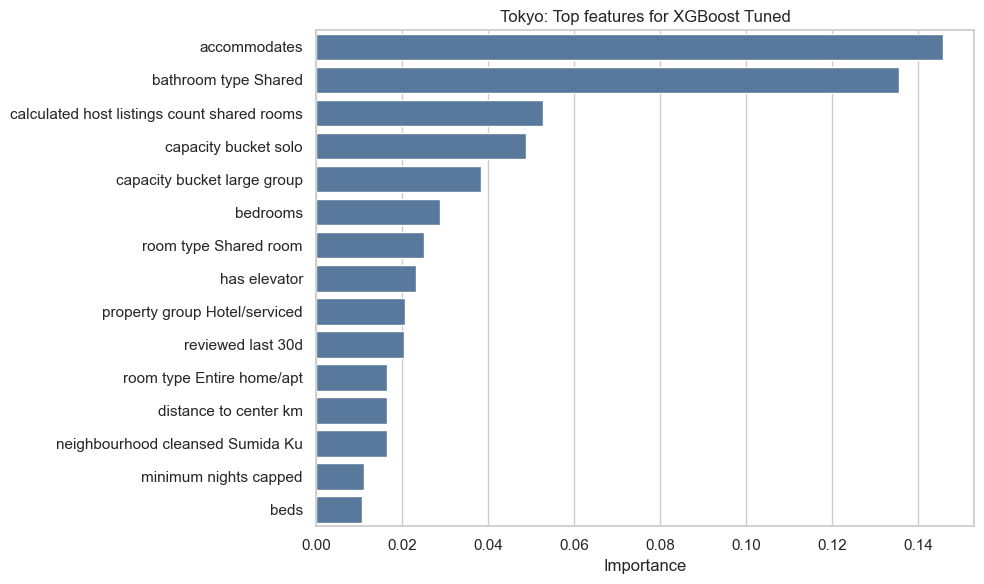

,city,model,feature,importance
1521,Madrid,CatBoost,room type Entire home/apt,21.982296
1295,Madrid,CatBoost,accommodates,7.709348
1292,Madrid,CatBoost,distance to center km,4.951292
1342,Madrid,CatBoost,minimum nights capped,4.801552
1298,Madrid,CatBoost,bathrooms,4.491684
1296,Madrid,CatBoost,bedrooms,3.704591
1290,Madrid,CatBoost,latitude,3.449268
1527,Madrid,CatBoost,bathroom type Shared,3.366896
1310,Madrid,CatBoost,host response rate,2.447650
1311,Madrid,CatBoost,host acceptance rate,1.870064


In [31]:
importance_rows = []

for city, models in trained_models.items():
    for model_name, pipeline in models.items():
        model = pipeline.named_steps["model"]
        if not hasattr(model, "feature_importances_"):
            continue

        feature_names = get_feature_names(pipeline)
        importances = model.feature_importances_

        for feature, importance in zip(feature_names, importances):
            importance_rows.append({
                "city": city,
                "model": model_name,
                "feature": feature,
                "importance": round(float(importance), 6),
            })

feature_importance_df = pd.DataFrame(importance_rows)
feature_importance_df.to_csv(OUTPUT_DIR / "expanded_city_feature_importance.csv", index=False)

for city in results_df["city"].unique():
    best_model_name = results_df[results_df["city"] == city].sort_values("rmse_eur").iloc[0]["model"]
    top_features = (
        feature_importance_df[
            (feature_importance_df["city"] == city)
            & (feature_importance_df["model"] == best_model_name)
        ]
        .sort_values("importance", ascending=False)
        .head(15)
    )

    if top_features.empty:
        continue

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_features, y="feature", x="importance", color="#4C78A8")
    plt.title(f"{city}: Top features for {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

display(feature_importance_df.sort_values(["city", "model", "importance"], ascending=[True, True, False]).head(30))

This cell extracts feature importance from the best available tree-based model for each city.

Feature importance helps explain what the tree-based models are using most. This is especially useful later when translating the modelling work into chatbot responses or project presentation points.


## 13. Error Segment Analysis


In [32]:
segment_rows = []
best_prediction_frames = []

for city in results_df["city"].unique():
    best_model_name = results_df[results_df["city"] == city].sort_values("rmse_eur").iloc[0]["model"]
    city_pred = predictions_df[
        (predictions_df["city"] == city)
        & (predictions_df["model"] == best_model_name)
    ].copy()
    city_pred["best_model"] = best_model_name
    best_prediction_frames.append(city_pred)

    city_pred["actual_price_band"] = pd.qcut(
        city_pred["actual_price_eur"],
        q=4,
        labels=["low", "mid-low", "mid-high", "high"],
        duplicates="drop",
    )

    possible_segments = [
        "room_type",
        "property_group",
        "capacity_bucket",
        "actual_price_band",
        "neighbourhood_cleansed",
    ]

    for segment_col in possible_segments:
        if segment_col not in city_pred.columns:
            continue

        grouped = (
            city_pred
            .groupby(segment_col, dropna=False)
            .agg(
                rows=("abs_error_eur", "size"),
                mae_eur=("abs_error_eur", "mean"),
                median_abs_error_eur=("abs_error_eur", "median"),
                p90_abs_error_eur=("abs_error_eur", lambda x: np.percentile(x, 90)),
                mean_actual_price_eur=("actual_price_eur", "mean"),
            )
            .reset_index()
            .rename(columns={segment_col: "segment"})
        )
        grouped = grouped[grouped["rows"] >= 30]
        grouped["city"] = city
        grouped["model"] = best_model_name
        grouped["segment_type"] = segment_col
        segment_rows.append(grouped)

best_predictions_df = pd.concat(best_prediction_frames, ignore_index=True)
error_segments_df = pd.concat(segment_rows, ignore_index=True)

for col in ["mae_eur", "median_abs_error_eur", "p90_abs_error_eur", "mean_actual_price_eur"]:
    error_segments_df[col] = error_segments_df[col].round(4)

best_predictions_df.to_csv(OUTPUT_DIR / "best_model_predictions.csv", index=False)
error_segments_df.to_csv(OUTPUT_DIR / "best_model_error_segments.csv", index=False)

display(error_segments_df.sort_values(["city", "segment_type", "mae_eur"], ascending=[True, True, False]).head(40))


,segment,rows,mae_eur,median_abs_error_eur,p90_abs_error_eur,mean_actual_price_eur,city,model,segment_type
15,high,875,37.7251,29.2266,80.3651,204.7634,Madrid,XGBoost Tuned,actual_price_band
14,mid-high,902,18.1001,14.2444,38.5276,127.7494,Madrid,XGBoost Tuned,actual_price_band
13,mid-low,883,15.8832,12.1825,34.1147,88.8448,Madrid,XGBoost Tuned,actual_price_band
12,low,894,10.2511,6.4766,24.3297,45.4306,Madrid,XGBoost Tuned,actual_price_band
9,large_group,119,36.5714,30.1108,79.9733,190.8992,Madrid,XGBoost Tuned,capacity_bucket
8,family_group,458,28.9864,23.7056,62.8557,169.4148,Madrid,XGBoost Tuned,capacity_bucket
10,small_group,1311,22.7865,15.6501,49.3241,133.2769,Madrid,XGBoost Tuned,capacity_bucket
7,couple,1248,17.2239,11.0364,38.7536,95.9471,Madrid,XGBoost Tuned,capacity_bucket
11,solo,418,8.4421,5.3299,19.6408,44.7033,Madrid,XGBoost Tuned,capacity_bucket
38,Rios Rosas,31,28.1030,23.6815,55.9170,120.0323,Madrid,XGBoost Tuned,neighbourhood_cleansed


This looks for where the best model still struggles. It groups prediction errors by room type, property group, capacity bucket, price band and neighbourhood.


## 14. Separate Models by Listing Type


In [33]:
listing_type_rows = []

for city, df in datasets.items():
    if "room_type" not in df.columns:
        continue

    city_best_overall = results_df[results_df["city"] == city].sort_values("rmse_eur").iloc[0]
    room_counts = df["room_type"].value_counts(dropna=False)
    print(f"{city} room type counts:")
    display(room_counts.to_frame("rows"))

    for room_type, rows in room_counts.items():
        if rows < 600:
            listing_type_rows.append({
                "city": city,
                "room_type": room_type,
                "rows": int(rows),
                "model": "XGBoost by room type",
                "status": "Skipped: fewer than 600 rows",
            })
            continue

        subset = df[df["room_type"] == room_type].copy()
        subset = subset.drop(columns=["room_type"])
        X, y, numeric_cols, categorical_cols = split_features(subset)
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
        )

        model = Pipeline(
            steps=[
                ("preprocess", build_preprocessor(numeric_cols, categorical_cols)),
                ("model", XGBRegressor(
                    n_estimators=300,
                    learning_rate=0.04,
                    max_depth=4,
                    subsample=0.85,
                    colsample_bytree=0.85,
                    objective="reg:squarederror",
                    eval_metric="rmse",
                    random_state=RANDOM_STATE,
                    n_jobs=MODEL_N_JOBS,
                )),
            ]
        )

        model.fit(X_train, y_train)
        y_pred_log = model.predict(X_test)
        metrics = evaluate_on_euros(y_test, y_pred_log)
        listing_type_rows.append({
            "city": city,
            "room_type": room_type,
            "rows": int(rows),
            "test_rows": len(X_test),
            "model": "XGBoost by room type",
            "status": "Modelled",
            "overall_best_model": city_best_overall["model"],
            "overall_best_rmse_eur": city_best_overall["rmse_eur"],
            **metrics,
        })

listing_type_results_df = pd.DataFrame(listing_type_rows)
listing_type_results_df.to_csv(OUTPUT_DIR / "listing_type_model_results.csv", index=False)
display(listing_type_results_df)


Madrid room type counts:


,rows
room_type,
Entire home/apt,12636
Private room,4949
Shared room,146
Hotel room,39


Tokyo room type counts:


,rows
room_type,
Entire home/apt,20513
Private room,2912
Shared room,254
Hotel room,86


,city,room_type,rows,test_rows,model,status,overall_best_model,overall_best_rmse_eur,rmse_eur,mae_eur,r2
0,Madrid,Entire home/apt,12636,2528.0,XGBoost by room type,Modelled,XGBoost Tuned,30.5866,34.8205,25.0302,0.6069
1,Madrid,Private room,4949,990.0,XGBoost by room type,Modelled,XGBoost Tuned,30.5866,27.3688,14.9239,0.6679
2,Madrid,Shared room,146,NaN,XGBoost by room type,Skipped: fewer than 600 rows,NaN,NaN,NaN,NaN,NaN
3,Madrid,Hotel room,39,NaN,XGBoost by room type,Skipped: fewer than 600 rows,NaN,NaN,NaN,NaN,NaN
4,Tokyo,Entire home/apt,20513,4103.0,XGBoost by room type,Modelled,XGBoost Tuned,28.5527,33.2037,23.0536,0.6368
5,Tokyo,Private room,2912,583.0,XGBoost by room type,Modelled,XGBoost Tuned,28.5527,28.7596,18.2845,0.7341
6,Tokyo,Shared room,254,NaN,XGBoost by room type,Skipped: fewer than 600 rows,NaN,NaN,NaN,NaN,NaN
7,Tokyo,Hotel room,86,NaN,XGBoost by room type,Skipped: fewer than 600 rows,NaN,NaN,NaN,NaN,NaN


This tests whether room-type-specific models are worth pursuing. The smaller groups are skipped because their metrics would be too unstable.


## 15. Auto-Generated Findings


In [34]:
summary_rows = []

for city in results_df["city"].unique():
    city_results = results_df[results_df["city"] == city].sort_values("rmse_eur")
    best = city_results.iloc[0]
    original = ORIGINAL_COMBINED_RESULTS["XGBoost"]
    summary_rows.append({
        "city": city,
        "best_model": best["model"],
        "best_rmse_eur": best["rmse_eur"],
        "best_mae_eur": best["mae_eur"],
        "best_r2": best["r2"],
        "rmse_improvement_vs_original_xgboost": round(original["rmse_eur"] - best["rmse_eur"], 4),
        "mae_improvement_vs_original_xgboost": round(original["mae_eur"] - best["mae_eur"], 4),
        "r2_improvement_vs_original_xgboost": round(best["r2"] - original["r2"], 4),
    })

recommendation_df = pd.DataFrame(summary_rows)
recommendation_df.to_csv(OUTPUT_DIR / "expanded_model_recommendation_summary.csv", index=False)
display(recommendation_df)

for _, row in recommendation_df.iterrows():
    print(
        f"{row['city']}: best model is {row['best_model']} "
        f"with RMSE {row['best_rmse_eur']:.2f}, MAE {row['best_mae_eur']:.2f}, "
        f"and R2 {row['best_r2']:.4f}."
    )


,city,best_model,best_rmse_eur,best_mae_eur,best_r2,rmse_improvement_vs_original_xgboost,mae_improvement_vs_original_xgboost,r2_improvement_vs_original_xgboost
0,Madrid,XGBoost Tuned,30.5866,20.4066,0.7624,6.2929,5.4682,0.1631
1,Tokyo,XGBoost Tuned,28.5527,18.9469,0.7372,8.3268,6.9279,0.1379


Madrid: best model is XGBoost Tuned with RMSE 30.59, MAE 20.41, and R2 0.7624.
Tokyo: best model is XGBoost Tuned with RMSE 28.55, MAE 18.95, and R2 0.7372.


The final table gives the headline recommendation from this expanded modelling round. The saved CSVs can be used directly in the report or presentation.
